## K-Nearest Neighbors (K-Vizinhos mais Próximos)

Dado um conjunto de observações

$$
V = \{(\vec{x_{i}}, y_{i})\}_{i=1}^{n}
$$
    
onde

$$
\vec{x_i} =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R^{d}} \quad
  y_i \in \mathbb{N}
$$

ou seja, $\vec{x_i}$ é um vetor de atributos e $y_i$ é um rótulo sendo, nesse caso, um valor discreto.

Vamos definir o conjunto de rótulos como sendo:

$$
C = \{ y_i \}_{i=1}^{m}, \quad m \leq n
$$

Dado um novo vetor de atributos $\vec{z}$, vamos calcular a distância Euclidiana entre $\vec{z}$ e todos os vetores de treino $\vec{x_i}$:

$$
d(\vec{z}, \vec{x_i}) = \sqrt{\sum_{k=1}^{d}(z_{k} - x_{ik})^{2}}
$$


Conseguimos assim determinar o vetor $\omega$, o vetor de distâncias de $\vec{z}$ a cada um dos $\vec{x_i}$

$$
\vec{\omega} =
\begin{bmatrix}
  d(\vec{z}, \vec{x_1}) \\ d(\vec{z}, \vec{x_2}) \\ \vdots \\ d(\vec{z}, \vec{x_n})
\end{bmatrix} \in \mathbb{R^{d}}
$$

Ordenando $\omega$, encontramos as $k$ menores distâncias e seus respectivos índices:

$$
I_k = \operatorname{arg sort}(\vec{\omega})_{1:k}
$$

Os rótulos correspondentes aos $k$ vizinhos mais próximos são então:

$$
\{y_{(1)}, y_{(2)}, \ldots, y_{(k)}\} \quad \text{onde } y_{(i)} = y_{I_k(i)}
$$


Por fim, dada a função indicadora $\mathbb{I}(\cdot)$:

$$
\mathbb{I}(A) =
\begin{cases}
1, & \text{se a condição } A \text{ é verdadeira} \\
0, & \text{caso contrário}
\end{cases}
$$


determinamos o rótulo predito $\hat{y}$ como sendo aquele que maximiza o número de ocorrências entre os $k$ vizinhos mais próximos:

$$
\hat{y} = \arg\max_{c \in C} \sum_{i=1}^{k} \mathbb{I}(y_{(i)} = c)
$$


## Aplicação

Uma loja de roupas online deseja recomendar automaticamente o tamanho ideal de camiseta para novos clientes, com base em suas medidas corporais. O objetivo é prever
$Y :=$ tamanho da camiseta (em categorias: *M* ou *L*),
a partir das variáveis
$X_1 :=$ altura do cliente (em cm) e
$X_2 :=$ peso do cliente (em kg).

A seguir, apresentam-se os dados coletados a partir de 18 observações de clientes anteriores:


| $n$  | 1   | 2   | 3   | 4   | 5   | 6   | 7   | 8   | 9   | 10  | 11  | 12  | 13  | 14  | 15  | 16  | 17  | 18  |
|----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| $X_1$ (Altura, cm) | 158 | 158 | 158 | 160 | 160 | 163 | 163 | 160 | 163 | 165 | 165 | 165 | 168 | 168 | 168 | 170 | 170 | 170 |
| $X_2$ (Peso, kg)   | 58  | 59  | 63  | 59  | 60  | 60  | 61  | 64  | 64  | 61  | 62  | 65  | 62  | 63  | 66  | 63  | 64  | 68  |
| $Y$ (Tamanho)     | M   | M   | M   | M   | M   | M   | M   | L   | L   | L   | L   | L   | L   | L   | L   | L   | L   | L   |

Responda às seguintes perguntas:

1. Os dados indicam que o *KNN* é eficaz para classificar o tamanho da camiseta a partir da altura e do peso?
2. Utilize o método *KNN* com $k = 3$ para classificar um novo cliente com $X_1 = 164~\text{cm}$ e $X_2 = 62~\text{kg}$.  
3. Quais são os três vizinhos mais próximos desse novo cliente no espaço das variáveis $(X_1, X_2)$?  
4. Qual é o tamanho predito $\hat{y}$ para esse cliente, de acordo com o voto majoritário dos vizinhos mais próximos?


### Solução

Gráfico de dispersão dos dados de teste:

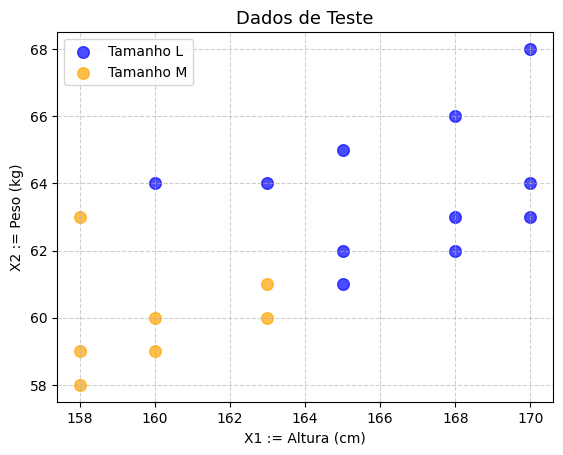

In [46]:
import numpy as np
import matplotlib.pyplot as plt

height = np.array([158, 158, 158, 160, 160, 163, 163,
                   160, 163, 165, 165, 165, 168, 168,
                   168, 170, 170, 170])

weight = np.array([58, 59, 63, 59, 60, 60, 61,
                   64, 64, 61, 62, 65, 62, 63,
                   66, 63, 64, 68])

size = np.array(['M', 'M', 'M', 'M', 'M', 'M', 'M',
                 'L', 'L', 'L', 'L', 'L', 'L', 'L',
                 'L', 'L', 'L', 'L'])

data = np.column_stack((height, weight))
labels = size

for classe, cor in zip(np.unique(labels), ['blue', 'orange']):
    pontos = data[labels == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Tamanho {classe}', color=cor, s=70, alpha=0.7)

plt.title('Dados de Teste', fontsize=13)
plt.xlabel('X1 := Altura (cm)')
plt.ylabel('X2 := Peso (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Os dados sugerem que um modelo de regressão múltipla descreve bem a relação entre as variáveis $X_1$, $X_2$ e $Y$.

Aplicação do algoritmo *KNN* para $X_1 = 164$ cm e $X_2 = 52$ kg

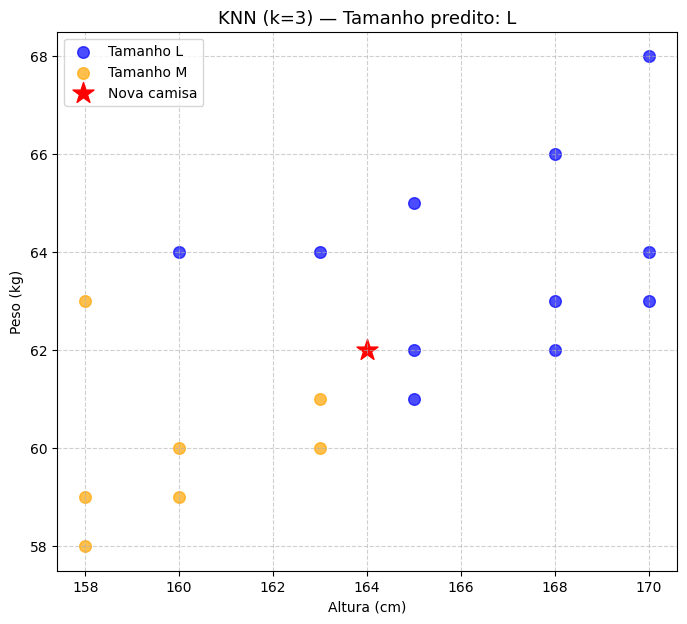

In [48]:
from collections import Counter
from math import sqrt

def dist(x, z):
    return sqrt(np.sum((np.array(x) - np.array(z))**2))

def knn(data, labels, z, k):
    omega = np.array([dist(x_i, z) for x_i in data])
    Ik = np.argsort(omega)[:k]
    Ck = labels[Ik]
    y = Counter(Ck).most_common(1)[0][0]
    return y, Ik

z = np.array([164, 62])
k = 3

label_pred, Ik = knn(data, labels, z, k)

plt.figure(figsize=(8, 7))

for classe, cor in zip(np.unique(labels), ['blue', 'orange']):
    pontos = data[labels == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Tamanho {classe}', color=cor, s=70, alpha=0.7)

plt.scatter(z[0], z[1], color='red', marker='*', s=250, label=f'Nova camisa')
plt.title(f'KNN (k={k}) — Tamanho predito: {label_pred}', fontsize=13)
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Dado $k = 3$, esses são os 3 vizinhos mais próximos de $z = (164, 62)$:

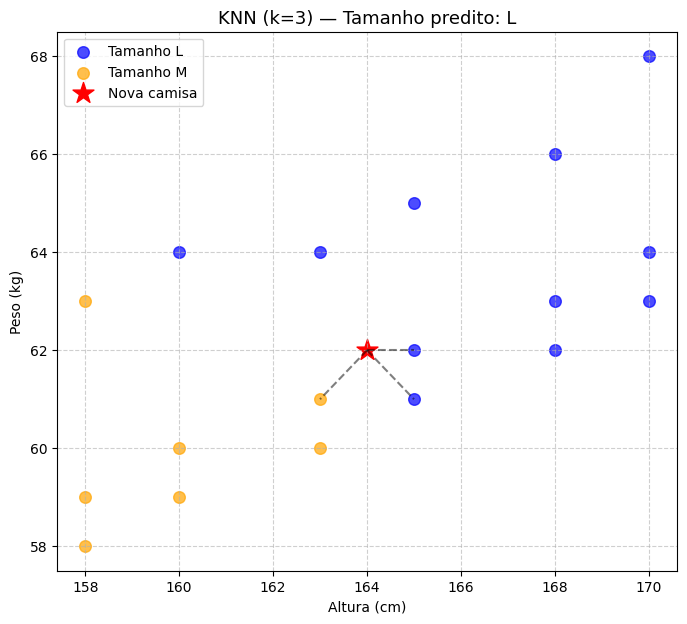

In [53]:
z = np.array([164, 62])
k = 3

label_pred, Ik = knn(data, labels, z, k)

plt.figure(figsize=(8, 7))

for classe, cor in zip(np.unique(labels), ['blue', 'orange']):
    pontos = data[labels == classe]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Tamanho {classe}', color=cor, s=70, alpha=0.7)

for i in Ik:
    plt.plot([z[0], data[i, 0]], [z[1], data[i, 1]], 'k--', alpha=0.5)

plt.scatter(z[0], z[1], color='red', marker='*', s=250, label=f'Nova camisa')
plt.title(f'KNN (k={k}) — Tamanho predito: {label_pred}', fontsize=13)
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Dessa forma, o tamanho $L$ é o que mais se adequa para $z$, dado os 3 vizinhos mais próximos.